In [1]:
import numpy as np
import pandas as pd
from copy import deepcopy
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def calc_feature(vals, lag, agg, window, i):
    if i - lag - window + 1 < 0:
        return None
    if agg == 'sum':
        ans = sum(vals[i - lag - window + 1:i - lag + 1])
    elif agg == 'mean':
        ans = sum(vals[i - lag - window + 1:i - lag + 1]) / window
    elif agg.startswith('percentile_'):
        prc = int(agg.split('_')[1])
        ans = np.percentile(np.array(vals[i - lag - window + 1:i - lag + 1]), prc)
    else:
        ans = None
    return ans

def lagged_features(data, date_col, cols, lags, agg_methods, windows):
    data = data.sort_values(date_col)
    res = deepcopy(data)

    for col in cols:
        for lag in lags:
            for agg in agg_methods:
                for window in windows:
                    values = []
                    for i in range(len(res)):
                        values.append(calc_feature(res[col].to_list(), lag, agg, window, i))
                    res[f'{col}_lag_{lag}_agg_{agg}_window_{window}'] = values
    
    return res.reset_index()


df = pd.read_pickle('electronika_clean.pkl')
df

,Order_ID,Email_new,Phone_new,Source,OrderDate,время,месяц,ChangeDate,DeliveryDate,PaymentDate,...,Quant,RowPrice,RowDiscount,RowSum,Brand,TN,TK,NomFullPath,Week,Nom_ID
2,1303000509_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,08:46:30.000,201603,2016-03-30 09:31:57.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,1.0,35999.0,0.0,35999.0,Samsung,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/Smart теле...",13.0,95567.0
4,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,3990.0,0.0,7980.0,NaN,NaN,NaN,Установка и настройка техники/Установка и наст...,13.0,2748.0
5,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,4490.0,0.0,8980.0,NaN,NaN,NaN,Установка и настройка техники/Установка и наст...,13.0,7874.0
7,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,32999.0,0.0,65998.0,Sony,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/Smart теле...",13.0,99485.0
8,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,999.0,0.0,1998.0,РЭМО,Аксессуары,Аксессуары ТВ-Аудио,"Телевизоры, аудио, видео/Аксессуары для ТВ/Ант...",13.0,20709.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357019,5898089_BX,6666449117_1u9@bk.ru,55574957-51495048515075,Онлайн-Резерв.,2016-04-30,23:51:37.000,201604,2016-05-03 12:55:07.000,2016-05-02 00:00:00.000,2016-05-02 00:10:22.000,...,1.0,899.0,0.0,899.0,Saturn,Климат,Вентиляторы бытовые,Техника для дома/Климатическая техника/Кондици...,17.0,38755.0
357021,5898095_BX,666661118109_vm27@yahoo.com,55575452-55554849505278,Онлайн-Резерв.,2016-04-30,23:54:03.000,201604,2016-05-04 19:43:40.000,2016-05-07 00:00:00.000,2016-05-04 19:43:41.000,...,1.0,1090.0,0.0,1090.0,Case Logic,Аксессуары,Аксессуары для фото/видео,Фото- и видеотехника/Аксессуары для фото и вид...,17.0,31908.0
357023,5898099_BX,3110116_nt16@pisem.net,55574948-50554849554878,Онлайн-Резерв.,2016-04-30,23:56:02.000,201604,2016-05-01 11:57:42.000,2016-05-08 00:00:00.000,1900-01-01 00:00:00.000,...,1.0,6859.0,0.0,6859.0,ELIKOR,Крупная бытовая техника,Встраиваемая техника,Встраиваемая техника/Вытяжки/,17.0,140459.0
357024,5898102_BX,55666665102117_fu13@list.ru,55575648-51484956545071,Онлайн-Резерв.,2016-04-30,23:56:38.000,201604,2016-05-06 20:18:49.000,2016-05-05 00:00:00.000,2016-05-06 20:18:50.000,...,1.0,9120.0,0.0,9120.0,FORWARD,Спорт и активный отдых,Велосипеды и аксессуары,Товары для спорта и отдыха/Велосипеды и аксесс...,17.0,295956.0


## Крупная бытовая техника

In [2]:
category_name = 'Крупная бытовая техника'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,RowSum,weekday,monthday,is_weekend
OrderDate,,,,
2016-03-01,9842440.0,1,1,0
2016-03-02,8274470.0,2,2,0
2016-03-03,8228073.0,3,3,0
2016-03-04,8198159.0,4,4,0
2016-03-05,14031438.0,5,5,1
2016-03-06,14055479.0,6,6,1
2016-03-07,11629947.0,0,7,0
2016-03-08,9301264.0,1,8,0
2016-03-09,7502038.0,2,9,0


In [3]:
params = [
    {
        'cols': ['RowSum'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'mean'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'percentile_50'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    }
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['RowSum', 'OrderDate'], axis=1)
    y = train_df.RowSum

    X_test = test_df.drop(['RowSum', 'OrderDate'], axis=1)
    y_test = test_df.RowSum

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


...

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 5


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [5]:
data_features = lagged_features(daily_sales, 'OrderDate', params[4]['cols'], params[4]['lags'], params[4]['agg'], params[4]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['RowSum', 'OrderDate'], axis=1)
y = train_df.RowSum

X_test = test_df.drop(['RowSum', 'OrderDate'], axis=1)
y_test = test_df.RowSum

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    plot=True
)

X_test = test_df.drop(['RowSum', 'OrderDate'], axis=1)
y_test = test_df.RowSum
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/481414787.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/481414787.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

,RowSum,weekday,monthday,is_weekend,Predictions
OrderDate,,,,,
2016-03-01,9842440.0,1,1,0,-1.000000e+00
2016-03-02,8274470.0,2,2,0,-1.000000e+00
2016-03-03,8228073.0,3,3,0,-1.000000e+00
2016-03-04,8198159.0,4,4,0,-1.000000e+00
2016-03-05,14031438.0,5,5,1,-1.000000e+00
...,...,...,...,...,...
2016-04-26,10120519.0,1,26,0,8.437870e+06
2016-04-27,8974232.0,2,27,0,8.383638e+06
2016-04-28,7676625.0,3,28,0,8.306110e+06


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1563025085.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


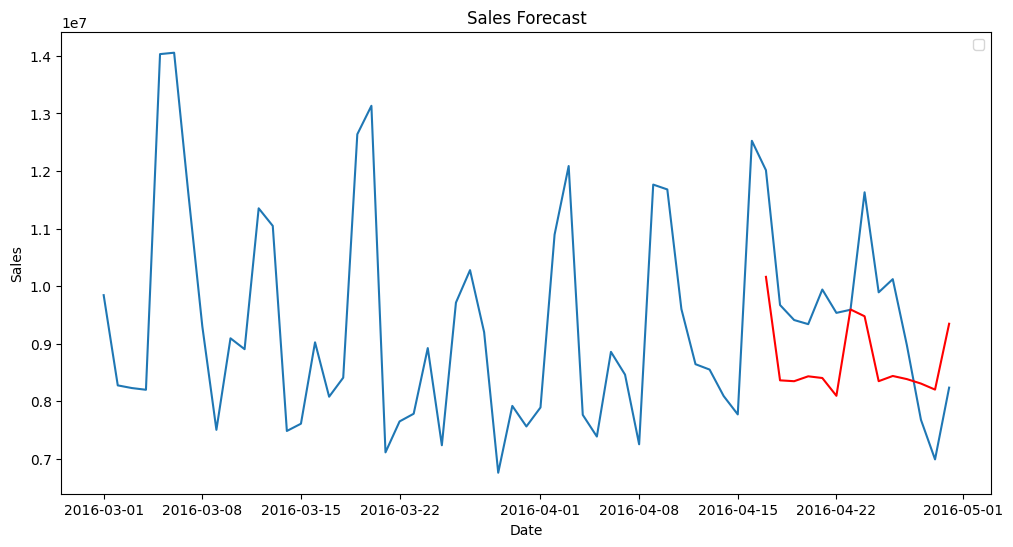

MAE: 1217212.0862304356
MSE: 1774916736579.3162
MAPE: 12.642339992031957


In [6]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.RowSum)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['RowSum'][-14:], predictions)
mse = mean_squared_error(daily_sales['RowSum'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['RowSum'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Сделай сам

In [7]:
category_name = 'Сделай сам'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,RowSum,weekday,monthday,is_weekend
OrderDate,,,,
2016-03-01,1642391.0,1,1,0
2016-03-02,1456211.0,2,2,0
2016-03-03,1887812.0,3,3,0
2016-03-04,1562647.0,4,4,0
2016-03-05,1225080.0,5,5,1
2016-03-06,1235666.0,6,6,1
2016-03-07,1328828.0,0,7,0
2016-03-08,1021276.0,1,8,0
2016-03-09,1603281.0,2,9,0


In [8]:
params = [
    {
        'cols': ['RowSum'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'mean'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'percentile_50'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    }
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['RowSum', 'OrderDate'], axis=1)
    y = train_df.RowSum

    X_test = test_df.drop(['RowSum', 'OrderDate'], axis=1)
    y_test = test_df.RowSum

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


...

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 5


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [9]:
data_features = lagged_features(daily_sales, 'OrderDate', params[0]['cols'], params[0]['lags'], params[0]['agg'], params[0]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['RowSum', 'OrderDate'], axis=1)
y = train_df.RowSum

X_test = test_df.drop(['RowSum', 'OrderDate'], axis=1)
y_test = test_df.RowSum

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    plot=True
)

X_test = test_df.drop(['RowSum', 'OrderDate'], axis=1)
y_test = test_df.RowSum
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/3746974891.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/3746974891.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

,RowSum,weekday,monthday,is_weekend,Predictions
OrderDate,,,,,
2016-03-01,1642391.0,1,1,0,-1.000000e+00
2016-03-02,1456211.0,2,2,0,-1.000000e+00
2016-03-03,1887812.0,3,3,0,-1.000000e+00
2016-03-04,1562647.0,4,4,0,-1.000000e+00
2016-03-05,1225080.0,5,5,1,-1.000000e+00
...,...,...,...,...,...
2016-04-26,3390182.0,1,26,0,2.023223e+06
2016-04-27,2872312.0,2,27,0,1.854019e+06
2016-04-28,2796143.0,3,28,0,2.067978e+06


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1563025085.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


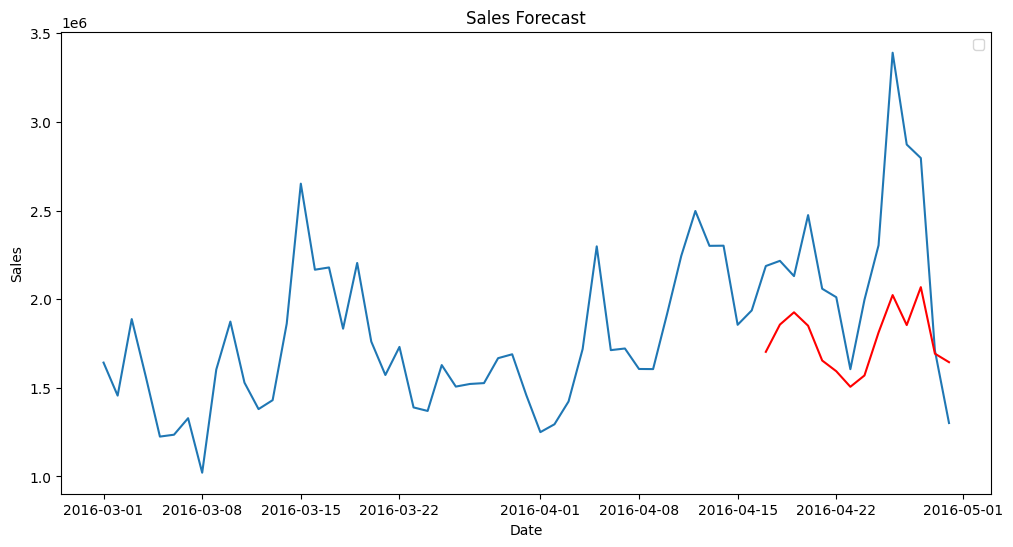

MAE: 498994.45276173216
MSE: 365746794686.76697
MAPE: 20.83452586585485


In [10]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.RowSum)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['RowSum'][-14:], predictions)
mse = mean_squared_error(daily_sales['RowSum'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['RowSum'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## ТВ-Аудио

In [11]:
category_name = 'ТВ-Аудио'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,RowSum,weekday,monthday,is_weekend
OrderDate,,,,
2016-03-01,4671151.0,1,1,0
2016-03-02,3430005.0,2,2,0
2016-03-03,3030830.0,3,3,0
2016-03-04,3016836.0,4,4,0
2016-03-05,4146939.0,5,5,1
2016-03-06,4430640.0,6,6,1
2016-03-07,3613510.0,0,7,0
2016-03-08,2740001.0,1,8,0
2016-03-09,2350809.0,2,9,0


In [12]:
params = [
    {
        'cols': ['RowSum'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'mean'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'percentile_50'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    }
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['RowSum', 'OrderDate'], axis=1)
    y = train_df.RowSum

    X_test = test_df.drop(['RowSum', 'OrderDate'], axis=1)
    y_test = test_df.RowSum

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


...

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 5


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1767992368.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [13]:
data_features = lagged_features(daily_sales, 'OrderDate', params[5]['cols'], params[5]['lags'], params[5]['agg'], params[5]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['RowSum', 'OrderDate'], axis=1)
y = train_df.RowSum

X_test = test_df.drop(['RowSum', 'OrderDate'], axis=1)
y_test = test_df.RowSum

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    plot=True
)

X_test = test_df.drop(['RowSum', 'OrderDate'], axis=1)
y_test = test_df.RowSum
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1396230820.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1396230820.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

,RowSum,weekday,monthday,is_weekend,Predictions
OrderDate,,,,,
2016-03-01,4671151.0,1,1,0,-1.000000e+00
2016-03-02,3430005.0,2,2,0,-1.000000e+00
2016-03-03,3030830.0,3,3,0,-1.000000e+00
2016-03-04,3016836.0,4,4,0,-1.000000e+00
2016-03-05,4146939.0,5,5,1,-1.000000e+00
...,...,...,...,...,...
2016-04-26,3919587.0,1,26,0,3.644319e+06
2016-04-27,2874065.0,2,27,0,3.611818e+06
2016-04-28,3202514.0,3,28,0,3.480782e+06


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_74042/1563025085.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


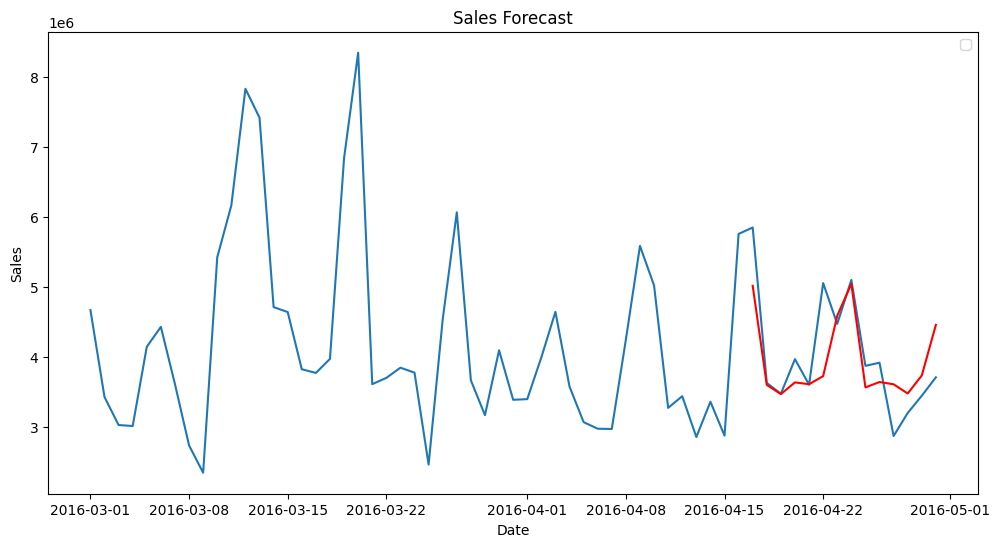

MAE: 381216.10436293244
MSE: 286507157523.36145
MAPE: 9.389916557836573


In [14]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.RowSum)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['RowSum'][-14:], predictions)
mse = mean_squared_error(daily_sales['RowSum'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['RowSum'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')